<a href="https://colab.research.google.com/github/lucasspoff-bit/Medical-Imaging-AI-Capstone/blob/main/notebooks/01_data_exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q medmnist

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 4.0 MB/s eta 0:00:00


In [2]:
import medmnist

print("MedMNIST version:", medmnist.__version__)

MedMNIST version: 3.0.2


In [3]:
from medmnist import ChestMNIST
from torchvision import transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = ChestMNIST(
    split="train",
    transform=transform,
    download=True
)

validation_dataset = ChestMNIST(
    split="val",
    transform=transform,
    download=True
)

test_dataset = ChestMNIST(
    split="test",
    transform=transform,
    download=True
)

print("Training images:", len(train_dataset))
print("Validation images:", len(validation_dataset))
print("Testing images:", len(test_dataset))

100%|██████████| 82.8M/82.8M [00:28<00:00, 2.95MB/s]


Training images: 78468
Validation images: 11219
Testing images: 22433


In [4]:
image, label = train_dataset[0]

print("Image shape:", image.shape)
print("Label shape:", label.shape)
print("Image minimum:", image.min().item())
print("Image maximum:", image.max().item())
print("Label:", label)

Image shape: torch.Size([1, 28, 28])
Label shape: (14,)
Image minimum: 0.01568627543747425
Image maximum: 0.9333333373069763
Label: [0 0 0 0 0 0 0 0 0 0 0 0 0 0]


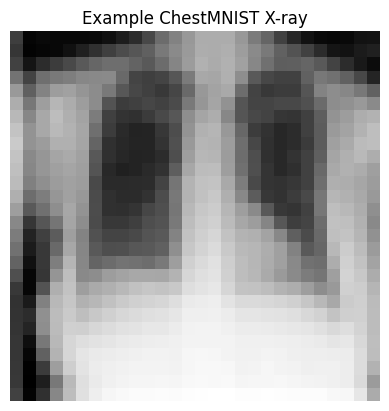

In [5]:
import matplotlib.pyplot as plt

plt.imshow(image.squeeze(), cmap="gray")
plt.title("Example ChestMNIST X-ray")
plt.axis("off")
plt.show()

In [6]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

images, labels = next(iter(train_loader))

print("Batch image shape:", images.shape)
print("Batch label shape:", labels.shape)

Batch image shape: torch.Size([32, 1, 28, 28])
Batch label shape: torch.Size([32, 14])


In [7]:
assert images.ndim == 4
assert images.shape[1] == 1
assert labels.ndim == 2
assert images.shape[0] == labels.shape[0]

print("All dataset checks passed.")

All dataset checks passed.


In [8]:
%%writefile requirements.txt
medmnist
torch
torchvision
matplotlib
numpy
pandas
scikit-learn

Writing requirements.txt
